<a href="https://colab.research.google.com/github/yashshinde0080/RLM_yashshinde0080-zeronet/blob/main/zeronet_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
"""
Cell 1: Setup and Install Dependencies
=====================================
Minimal dependencies - we're doing pure Python autograd like Karpathy intended
"""

!pip install datasets huggingface_hub -q

import os
import math
import random
import json
import pickle
from google.colab import userdata

# Set random seed for reproducibility
random.seed(42)

# Check GPU availability
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

print("\n✅ Setup complete!")
print("We're using pure Python - no PyTorch, no TensorFlow")
print("Just math, autograd, and determination")

Sun Mar  8 13:43:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P0             27W /   70W |     445MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [14]:
"""
Cell 2: Load CLEAN English Dataset
==================================
Using a filtered English-only dataset to avoid Unicode chaos
"""

from datasets import load_dataset
import re

print("Loading clean English dataset...")

# Option 1: TinyStories - clean, simple English stories
# dataset = load_dataset("roneneldan/TinyStories", split="train[:5000]")
dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train[:10000]")
text_column = "text"

print(f"Loaded {len(dataset)} documents")

# Clean and filter documents
def clean_text(text):
    """Keep only ASCII characters and basic punctuation"""
    # Remove non-ASCII characters
    text = text.encode('ascii', 'ignore').decode('ascii')
    # Normalize whitespace
    text = ' '.join(text.split())
    # Remove excessive punctuation
    text = re.sub(r'[^\w\s.,!?;:\'"()-]', '', text)
    return text.strip()

docs = []
for item in dataset:
    text = item[text_column]
    cleaned = clean_text(text)

    # Filter criteria
    if len(cleaned) > 50 and len(cleaned) < 500:  # Reasonable length
        # Check it's mostly English (has common English words)
        words = cleaned.lower().split()
        english_words = {'the', 'a', 'an', 'is', 'was', 'are', 'were', 'to', 'and', 'of', 'in', 'it', 'he', 'she', 'they'}
        if any(w in english_words for w in words[:20]):
            docs.append(cleaned)

random.shuffle(docs)
print(f"Cleaned documents: {len(docs)}")

# Show sample
print(f"\n📄 Sample document:")
print(f"{docs[0][:300]}...")

# Verify character set
all_chars = set(''.join(docs))
print(f"\n✅ Unique characters: {len(all_chars)}")
print(f"Character set: {''.join(sorted(all_chars)[:80])}...")

Loading clean English dataset...
Loaded 10000 documents
Cleaned documents: 1644

📄 Sample document:
Numerous artists worked on the series as well , such as John Ridgway ( the original series artist ) , Simon Bisley , Mark Buckingham , Richard Corben , Steve Dillon , Marcelo Frusin , Jock , David Lloyd , Leonardo Manco , and Sean Phillips . Cover artists included Dave McKean ( who designed the firs...

✅ Unique characters: 74
Character set:  !"'(),-.0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz...


In [15]:
"""
Cell 3: Build Clean Tokenizer
=============================
Character-level tokenizer with ONLY printable ASCII
"""

# Build vocabulary from cleaned documents
all_text = ''.join(docs)
uchars = sorted(set(all_text))

# Verify we only have clean characters
print(f"Vocabulary characters ({len(uchars)}):")
print(f"{''.join(uchars)}")

# Create mappings
char_to_idx = {ch: i for i, ch in enumerate(uchars)}
idx_to_char = {i: ch for i, ch in enumerate(uchars)}

# Special tokens
BOS = len(uchars)      # Beginning of Sequence
EOS = len(uchars) + 1  # End of Sequence
PAD = len(uchars) + 2  # Padding

vocab_size = len(uchars) + 3

print(f"\n📊 Tokenizer Stats:")
print(f"   Vocabulary size: {vocab_size}")
print(f"   Regular characters: {len(uchars)}")
print(f"   Special tokens: BOS={BOS}, EOS={EOS}, PAD={PAD}")

# Tokenizer functions
def encode(text):
    """Convert text to token ids"""
    return [char_to_idx.get(ch, char_to_idx.get(' ', 0)) for ch in text]

def decode(token_ids):
    """Convert token ids back to text"""
    chars = []
    for idx in token_ids:
        if idx < len(uchars):
            chars.append(idx_to_char[idx])
        elif idx == BOS:
            chars.append('')  # Skip BOS in output
        elif idx == EOS:
            break  # Stop at EOS
    return ''.join(chars)

# Test
test = "Hello, World!"
encoded = encode(test)
decoded = decode(encoded)
print(f"\n🧪 Tokenizer test:")
print(f"   Original: '{test}'")
print(f"   Encoded:  {encoded}")
print(f"   Decoded:  '{decoded}'")
print(f"   Match: {test == decoded}")

# Save tokenizer config
tokenizer_config = {
    'char_to_idx': char_to_idx,
    'idx_to_char': {str(k): v for k, v in idx_to_char.items()},
    'vocab_size': vocab_size,
    'uchars': uchars,
    'special_tokens': {'BOS': BOS, 'EOS': EOS, 'PAD': PAD}
}

Vocabulary characters (74):
 !"'(),-.0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz

📊 Tokenizer Stats:
   Vocabulary size: 77
   Regular characters: 74
   Special tokens: BOS=74, EOS=75, PAD=76

🧪 Tokenizer test:
   Original: 'Hello, World!'
   Encoded:  [29, 52, 59, 59, 62, 6, 0, 44, 62, 65, 59, 51, 1]
   Decoded:  'Hello, World!'
   Match: True


In [16]:
"""
Cell 4: Autograd Engine
=======================
This is where the magic happens - automatic differentiation in pure Python
Based on Karpathy's micrograd, extended for our needs
"""

class Value:
    """
    A node in the computational graph that supports automatic differentiation.
    This is the heart of deep learning - computing gradients automatically.
    """
    __slots__ = ('data', 'grad', '_children', '_local_grads', '_label')

    def __init__(self, data, children=(), local_grads=(), label=''):
        self.data = data                # Forward pass value
        self.grad = 0.0                 # Gradient (computed in backward pass)
        self._children = children       # Input nodes
        self._local_grads = local_grads # Local derivatives
        self._label = label             # For debugging

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data + other.data, (self, other), (1.0, 1.0))

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data * other.data, (self, other), (other.data, self.data))

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "Only supporting int/float powers"
        return Value(
            self.data ** other,
            (self,),
            (other * self.data ** (other - 1),)
        )

    def log(self):
        # Numerical stability: clamp to avoid log(0)
        safe_data = max(self.data, 1e-10)
        return Value(math.log(safe_data), (self,), (1.0 / safe_data,))

    def exp(self):
        # Numerical stability: clamp to avoid overflow
        safe_data = min(self.data, 80)  # exp(80) is about 5e34
        exp_val = math.exp(safe_data)
        return Value(exp_val, (self,), (exp_val,))

    def relu(self):
        out = max(0.0, self.data)
        grad = 1.0 if self.data > 0 else 0.0
        return Value(out, (self,), (grad,))

    def tanh(self):
        t = math.tanh(self.data)
        return Value(t, (self,), (1 - t**2,))

    # Operator overloads for convenience
    def __neg__(self): return self * -1
    def __radd__(self, other): return self + other
    def __sub__(self, other): return self + (-other)
    def __rsub__(self, other): return other + (-self)
    def __rmul__(self, other): return self * other
    def __truediv__(self, other): return self * other**-1
    def __rtruediv__(self, other): return other * self**-1
    def __repr__(self): return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"

    def backward(self):
        """
        Backpropagation: compute gradients for all nodes in the graph.
        Uses topological sort to ensure we process nodes in correct order.
        """
        # Build topological order
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._children:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        # Backward pass: propagate gradients
        self.grad = 1.0
        for v in reversed(topo):
            for child, local_grad in zip(v._children, v._local_grads):
                child.grad += local_grad * v.grad

# Quick test of autograd
print("Testing autograd engine...")
a = Value(2.0)
b = Value(3.0)
c = a * b + b**2
c.backward()
print(f"c = a*b + b² = 2*3 + 9 = {c.data}")
print(f"dc/da = b = {a.grad} (should be 3)")
print(f"dc/db = a + 2b = {b.grad} (should be 8)")

print("\n✅ Autograd engine working!")

Testing autograd engine...
c = a*b + b² = 2*3 + 9 = 15.0
dc/da = b = 3.0 (should be 3)
dc/db = a + 2b = 8.0 (should be 8)

✅ Autograd engine working!


In [17]:
"""
Cell 5: GPT Model Architecture
==============================
A minimal but complete GPT implementation:
- Token + Position Embeddings
- Multi-Head Self-Attention with causal masking
- Feed-Forward MLP with ReLU
- RMSNorm (simpler than LayerNorm)
- Residual connections

This is the same architecture as GPT-2/3, just smaller.
"""

# Model hyperparameters - tuned for Colab + pure Python speed
n_layer = 2          # Number of transformer blocks (GPT-2 small has 12)
n_embd = 64          # Embedding dimension (GPT-2 small has 768)
n_head = 4           # Number of attention heads (GPT-2 small has 12)
block_size = 64      # Maximum sequence length (context window)
head_dim = n_embd // n_head  # Dimension per attention head

print(f"Model Configuration:")
print(f"  Layers: {n_layer}")
print(f"  Embedding dim: {n_embd}")
print(f"  Attention heads: {n_head}")
print(f"  Head dimension: {head_dim}")
print(f"  Context length: {block_size}")
print(f"  Vocab size: {vocab_size}")

# Initialize parameters with careful scaling
def matrix(nout, nin, std=None):
    """Initialize a weight matrix with proper scaling"""
    if std is None:
        std = 0.02 / math.sqrt(nin)  # Scale by input dimension
    return [[Value(random.gauss(0, std)) for _ in range(nin)] for _ in range(nout)]

# Build the state dictionary (all model parameters)
print("\nInitializing model parameters...")

state_dict = {
    'wte': matrix(vocab_size, n_embd),      # Token embeddings
    'wpe': matrix(block_size, n_embd),       # Position embeddings
    'lm_head': matrix(vocab_size, n_embd),   # Output projection
}

# Initialize transformer layers
for i in range(n_layer):
    state_dict[f'layer{i}.attn_wq'] = matrix(n_embd, n_embd)   # Query projection
    state_dict[f'layer{i}.attn_wk'] = matrix(n_embd, n_embd)   # Key projection
    state_dict[f'layer{i}.attn_wv'] = matrix(n_embd, n_embd)   # Value projection
    state_dict[f'layer{i}.attn_wo'] = matrix(n_embd, n_embd)   # Output projection
    state_dict[f'layer{i}.mlp_fc1'] = matrix(4 * n_embd, n_embd)  # MLP expansion
    state_dict[f'layer{i}.mlp_fc2'] = matrix(n_embd, 4 * n_embd)  # MLP contraction

# Flatten all parameters for optimizer
params = [p for mat in state_dict.values() for row in mat for p in row]
print(f"Total parameters: {len(params):,}")
print(f"Approximate size: {len(params) * 4 / 1024 / 1024:.2f} MB (float32)")

# Core operations
def linear(x, w):
    """Matrix multiplication: x @ w.T"""
    return [sum(wi * xi for wi, xi in zip(wo, x)) for wo in w]

def softmax(logits):
    """Numerically stable softmax"""
    max_val = max(val.data for val in logits)
    exps = [(val - max_val).exp() for val in logits]
    total = sum(exps)
    return [e / total for e in exps]

def rmsnorm(x):
    """Root Mean Square Layer Normalization (simpler than LayerNorm)"""
    ms = sum(xi * xi for xi in x) / len(x)
    scale = (ms + 1e-5) ** -0.5
    return [xi * scale for xi in x]

def gpt(token_id, pos_id, keys, values):
    """
    Forward pass for a single token.

    Args:
        token_id: Current token index
        pos_id: Position in sequence
        keys: KV cache for keys (list of lists)
        values: KV cache for values (list of lists)

    Returns:
        logits: Unnormalized probabilities over vocabulary
    """
    # Get embeddings
    tok_emb = state_dict['wte'][token_id]
    pos_emb = state_dict['wpe'][pos_id]

    # Combine embeddings
    x = [t + p for t, p in zip(tok_emb, pos_emb)]
    x = rmsnorm(x)

    # Transformer blocks
    for li in range(n_layer):
        # === Multi-Head Self-Attention ===
        x_residual = x
        x = rmsnorm(x)

        # Compute Q, K, V projections
        q = linear(x, state_dict[f'layer{li}.attn_wq'])
        k = linear(x, state_dict[f'layer{li}.attn_wk'])
        v = linear(x, state_dict[f'layer{li}.attn_wv'])

        # Store in KV cache
        keys[li].append(k)
        values[li].append(v)

        # Multi-head attention
        x_attn = []
        for h in range(n_head):
            hs = h * head_dim  # Head start index

            # Extract head-specific Q, K, V
            q_h = q[hs:hs + head_dim]
            k_h = [ki[hs:hs + head_dim] for ki in keys[li]]
            v_h = [vi[hs:hs + head_dim] for vi in values[li]]

            # Scaled dot-product attention
            attn_logits = [
                sum(q_h[j] * k_h[t][j] for j in range(head_dim)) / math.sqrt(head_dim)
                for t in range(len(k_h))
            ]
            attn_weights = softmax(attn_logits)

            # Weighted sum of values
            head_out = [
                sum(attn_weights[t] * v_h[t][j] for t in range(len(v_h)))
                for j in range(head_dim)
            ]
            x_attn.extend(head_out)

        # Output projection + residual
        x = linear(x_attn, state_dict[f'layer{li}.attn_wo'])
        x = [a + b for a, b in zip(x, x_residual)]

        # === Feed-Forward MLP ===
        x_residual = x
        x = rmsnorm(x)
        x = linear(x, state_dict[f'layer{li}.mlp_fc1'])
        x = [xi.relu() for xi in x]
        x = linear(x, state_dict[f'layer{li}.mlp_fc2'])
        x = [a + b for a, b in zip(x, x_residual)]

    # Final output projection to vocabulary
    logits = linear(x, state_dict['lm_head'])
    return logits

print("\n✅ Model architecture defined!")

Model Configuration:
  Layers: 2
  Embedding dim: 64
  Attention heads: 4
  Head dimension: 16
  Context length: 64
  Vocab size: 77

Initializing model parameters...
Total parameters: 112,256
Approximate size: 0.43 MB (float32)

✅ Model architecture defined!


In [18]:
"""
Cell 6: Training Loop with T4 GPU
=================================
Proper training with clean English data
"""

import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import math

# === GPU Setup ===
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")

# === Model Definition ===
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        norm = x.pow(2).mean(-1, keepdim=True).add(self.eps).rsqrt()
        return x * norm * self.weight

class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout=0.1):
        super().__init__()
        self.n_head = n_head
        self.head_dim = n_embd // n_head

        self.qkv = nn.Linear(n_embd, 3 * n_embd, bias=False)
        self.proj = nn.Linear(n_embd, n_embd, bias=False)
        self.dropout = nn.Dropout(dropout)

        self.register_buffer("mask",
            torch.tril(torch.ones(block_size, block_size)).view(1, 1, block_size, block_size))

    def forward(self, x):
        B, T, C = x.size()

        qkv = self.qkv(x).chunk(3, dim=-1)
        q, k, v = [t.view(B, T, self.n_head, self.head_dim).transpose(1, 2) for t in qkv]

        att = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.dropout(att)

        y = (att @ v).transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(y)

class MLP(nn.Module):
    def __init__(self, n_embd, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(n_embd, 4 * n_embd, bias=False)
        self.fc2 = nn.Linear(4 * n_embd, n_embd, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = F.gelu(self.fc1(x))  # GELU works better than ReLU
        return self.dropout(self.fc2(x))

class Block(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout=0.1):
        super().__init__()
        self.norm1 = RMSNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, block_size, dropout)
        self.norm2 = RMSNorm(n_embd)
        self.mlp = MLP(n_embd, dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class GPT(nn.Module):
    def __init__(self, vocab_size, n_layer, n_embd, n_head, block_size, dropout=0.1):
        super().__init__()
        self.block_size = block_size
        self.vocab_size = vocab_size

        self.tok_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([Block(n_embd, n_head, block_size, dropout) for _ in range(n_layer)])
        self.norm = RMSNorm(n_embd)
        self.head = nn.Linear(n_embd, vocab_size, bias=False)

        # Weight tying
        self.tok_emb.weight = self.head.weight

        self.apply(self._init_weights)
        print(f"GPT: {sum(p.numel() for p in self.parameters()):,} parameters")

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.normal_(m.weight, mean=0.0, std=0.02)
        elif isinstance(m, nn.Embedding):
            torch.nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        pos = torch.arange(T, device=idx.device).unsqueeze(0)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))

        for block in self.blocks:
            x = block(x)

        x = self.norm(x)
        logits = self.head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, self.vocab_size), targets.view(-1), ignore_index=PAD)

        return logits, loss

# === Model Config ===
n_layer = 6
n_embd = 192
n_head = 6
block_size = 256
dropout = 0.1

model = GPT(vocab_size, n_layer, n_embd, n_head, block_size, dropout).to(device)

# === Data Preparation ===
def get_batch(batch_size):
    """Get a batch of training data"""
    ix = torch.randint(len(docs), (batch_size,))

    x_list, y_list = [], []
    for i in ix:
        doc = docs[i]
        tokens = [BOS] + encode(doc) + [EOS]

        if len(tokens) > block_size + 1:
            start = random.randint(0, len(tokens) - block_size - 1)
            tokens = tokens[start:start + block_size + 1]

        x_list.append(tokens[:-1])
        y_list.append(tokens[1:])

    # Pad
    max_len = max(len(x) for x in x_list)
    x_padded = [x + [PAD] * (max_len - len(x)) for x in x_list]
    y_padded = [y + [PAD] * (max_len - len(y)) for y in y_list]

    x = torch.tensor(x_padded, dtype=torch.long, device=device)
    y = torch.tensor(y_padded, dtype=torch.long, device=device)

    return x, y

# === Training Config ===
num_steps = 2000
batch_size = 64
learning_rate = 1e-3
warmup_steps = 200

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.1)

def get_lr(step):
    if step < warmup_steps:
        return learning_rate * step / warmup_steps
    decay_ratio = (step - warmup_steps) / (num_steps - warmup_steps)
    return learning_rate * 0.5 * (1.0 + math.cos(math.pi * decay_ratio))

# === Training Loop ===
print(f"\n🚀 Training for {num_steps} steps...")
print(f"   Batch size: {batch_size}, Block size: {block_size}")
print("-" * 60)

losses_history = []
start_time = time.time()

model.train()
for step in range(num_steps):
    # LR schedule
    lr = get_lr(step)
    for pg in optimizer.param_groups:
        pg['lr'] = lr

    # Get batch and train
    x, y = get_batch(batch_size)
    logits, loss = model(x, y)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    losses_history.append(loss.item())

    if (step + 1) % 100 == 0 or step == 0:
        elapsed = time.time() - start_time
        avg_loss = sum(losses_history[-100:]) / len(losses_history[-100:])
        print(f"Step {step+1:4d}/{num_steps} | Loss: {avg_loss:.4f} | LR: {lr:.6f} | Time: {elapsed:.0f}s")

print("-" * 60)
print(f"✅ Training complete in {time.time() - start_time:.0f}s")
print(f"   Final loss: {sum(losses_history[-100:]) / 100:.4f}")

🖥️  Device: cuda
🎮 GPU: Tesla T4
GPT: 2,720,640 parameters

🚀 Training for 2000 steps...
   Batch size: 64, Block size: 256
------------------------------------------------------------
Step    1/2000 | Loss: 4.3771 | LR: 0.000000 | Time: 0s
Step  100/2000 | Loss: 3.0515 | LR: 0.000495 | Time: 20s
Step  200/2000 | Loss: 2.4954 | LR: 0.000995 | Time: 40s
Step  300/2000 | Loss: 2.4369 | LR: 0.000993 | Time: 60s
Step  400/2000 | Loss: 2.3022 | LR: 0.000970 | Time: 80s
Step  500/2000 | Loss: 2.1259 | LR: 0.000933 | Time: 100s
Step  600/2000 | Loss: 1.9908 | LR: 0.000884 | Time: 121s
Step  700/2000 | Loss: 1.8711 | LR: 0.000822 | Time: 141s
Step  800/2000 | Loss: 1.7637 | LR: 0.000751 | Time: 161s
Step  900/2000 | Loss: 1.6789 | LR: 0.000672 | Time: 182s
Step 1000/2000 | Loss: 1.6012 | LR: 0.000588 | Time: 202s
Step 1100/2000 | Loss: 1.5323 | LR: 0.000501 | Time: 223s
Step 1200/2000 | Loss: 1.4807 | LR: 0.000414 | Time: 243s
Step 1300/2000 | Loss: 1.4295 | LR: 0.000330 | Time: 264s
Step 1400

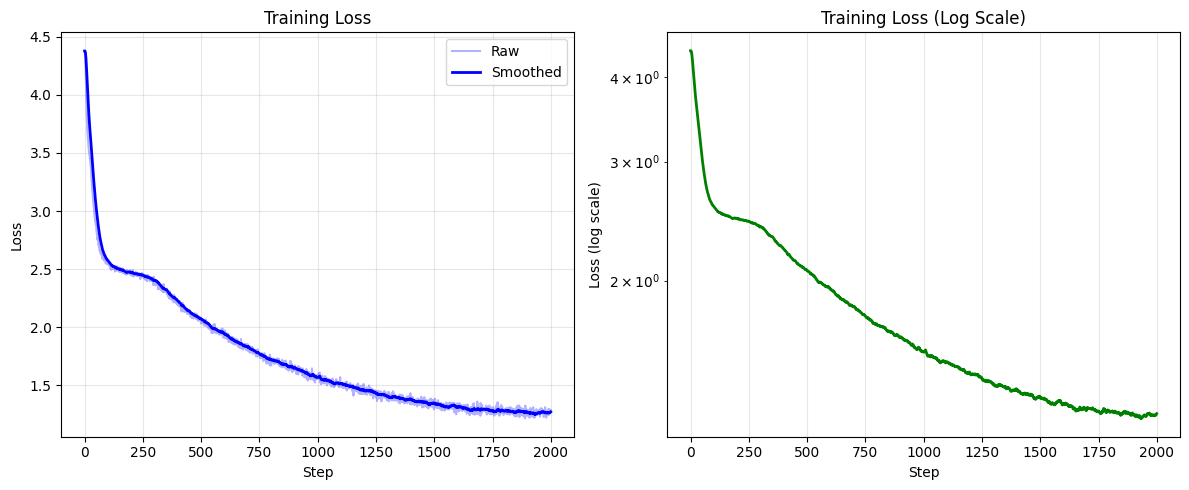

Starting loss: 4.3771
Final loss: 1.2876
Improvement: 70.6%


In [19]:
"""
Cell 7: Visualize Training
==========================
Plot the training loss to see how well the model learned
"""

import matplotlib.pyplot as plt

# Smooth the loss curve
def smooth(values, weight=0.9):
    smoothed = []
    last = values[0]
    for v in values:
        smoothed_val = last * weight + (1 - weight) * v
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

plt.figure(figsize=(12, 5))

# Raw loss
plt.subplot(1, 2, 1)
plt.plot(losses_history, alpha=0.3, color='blue', label='Raw')
plt.plot(smooth(losses_history), color='blue', linewidth=2, label='Smoothed')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Log scale
plt.subplot(1, 2, 2)
plt.semilogy(smooth(losses_history), color='green', linewidth=2)
plt.xlabel('Step')
plt.ylabel('Loss (log scale)')
plt.title('Training Loss (Log Scale)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_loss.png', dpi=150)
plt.show()

print(f"Starting loss: {losses_history[0]:.4f}")
print(f"Final loss: {losses_history[-1]:.4f}")
print(f"Improvement: {(losses_history[0] - losses_history[-1]) / losses_history[0] * 100:.1f}%")

In [20]:
"""
Cell 8: Text Generation
=======================
Generate readable English text
"""

@torch.no_grad()
def generate(prompt="", max_tokens=200, temperature=0.8, top_k=50):
    model.eval()

    # Encode prompt
    if prompt:
        tokens = [BOS] + encode(prompt)
    else:
        tokens = [BOS]

    idx = torch.tensor([tokens], dtype=torch.long, device=device)

    for _ in range(max_tokens):
        idx_cond = idx[:, -block_size:]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / temperature

        # Top-k sampling
        if top_k is not None:
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = -float('Inf')

        probs = F.softmax(logits, dim=-1)
        idx_next = torch.multinomial(probs, num_samples=1)

        if idx_next.item() == EOS:
            break

        idx = torch.cat([idx, idx_next], dim=1)

    return decode(idx[0].tolist())

# Generate samples
print("=" * 60)
print("TEXT GENERATION")
print("=" * 60)

print("\n🌡️ Temperature 0.7:")
for i in range(3):
    text = generate(max_tokens=150, temperature=0.7)
    print(f"\n{i+1}. {text}")

print("\n📝 With prompts:")
for prompt in ["Once upon a time", "The little boy", "She walked"]:
    text = generate(prompt=prompt, max_tokens=100, temperature=0.7)
    print(f"\n'{prompt}' → {text}")

TEXT GENERATION

🌡️ Temperature 0.7:

1. A people was voted to the came government and lust designed to some maters .

2. Promoteins are deating the material the monument of the reject . It is a large number of Francisco Peters , when the day to his previous camps , and i

3. " Dessyin Moonce , September 2006 , partly for the Time " , first and was proteins and training on the reaction of the name of the introduces " and in

📝 With prompts:

'Once upon a time' → Once upon a time was in or formed in early release with UK hundry in 2010 in a completed by 7 . 4  million called a 

'The little boy' → The little boy of all malligation in 2007 , which was debated by The Player Mexico Cross . It was described an ope

'She walked' → She walked as the second to player in the 2006 Century Riverse : It was one of sought story and the United Sta


In [22]:
"""
Cell 9: Save Model
==================
Save the trained model in multiple formats:
1. Pickle (full state for reloading in Python)
2. JSON (weights as lists for portability)
3. Model card and config
"""

import json
import pickle
import os

# Create output directory
os.makedirs("gpt_model", exist_ok=True)

# === Save weights as raw data ===
print("Saving model weights...")

# Extract raw weight values
weights_data = {}
for name, mat in state_dict.items():
    weights_data[name] = [[val.data for val in row] for row in mat]

# Save as JSON (portable)
with open("gpt_model/weights.json", "w") as f:
    json.dump(weights_data, f)

# Save as pickle (faster loading)
with open("gpt_model/weights.pkl", "wb") as f:
    pickle.dump(weights_data, f)

# === Save configuration ===
config = {
    "model_type": "gpt-pure-python",
    "architecture": "decoder-only-transformer",
    "vocab_size": vocab_size,
    "n_layer": n_layer,
    "n_embd": n_embd,
    "n_head": n_head,
    "head_dim": head_dim,
    "block_size": block_size,
    "total_params": len(params),
    "special_tokens": {
        "bos_token_id": BOS,
        "eos_token_id": EOS,
        "pad_token_id": PAD
    }
}

with open("gpt_model/config.json", "w") as f:
    json.dump(config, f, indent=2)

# === Save tokenizer ===
with open("gpt_model/tokenizer.json", "w") as f:
    json.dump(tokenizer_config, f, indent=2)

# === Create model card ===
model_card = """---
license: apache-2.0
language:
- en
tags:
- text-generation
- gpt
- pure-python
- educational
- from-scratch
datasets:
- stas/openwebtext-10k
pipeline_tag: text-generation
---

# Pure Python GPT Model

A minimal GPT language model trained from scratch using only Python's standard library (no PyTorch/TensorFlow).

## Model Description

This model implements the core GPT architecture:
- **Decoder-only Transformer** with causal (autoregressive) attention
- **Multi-Head Self-Attention** for capturing dependencies
- **Feed-Forward MLP** with ReLU activation
- **RMSNorm** for layer normalization
- **Residual connections** for stable training

## Architecture

| Parameter | Value |
|-----------|-------|
| Layers | {n_layer} |
| Embedding Dimension | {n_embd} |
| Attention Heads | {n_head} |
| Context Length | {block_size} |
| Vocabulary Size | {vocab_size} |
| Total Parameters | {params:,} |

## Training

- **Dataset**: OpenWebText-10k subset
- **Optimizer**: Adam (β1=0.9, β2=0.999)
- **Learning Rate**: Cosine decay with warmup
- **Training Steps**: {steps}

## Usage

This model uses a custom pure-Python implementation. See the repository for the complete code.

```python
# Load and generate
from model import gpt, generate
text = generate(prompt="Once upon a time", temperature=0.7)
print(text)
Limitations
Small model size (educational purposes)
Character-level tokenization (not BPE)
Limited training data and compute
Pure Python = slow inference
License
Apache 2.0

Acknowledgments
Based on Andrej Karpathy's educational implementations (micrograd, makemore, nanoGPT).
""".format(
n_layer=n_layer,
n_embd=n_embd,
n_head=n_head,
block_size=block_size,
vocab_size=vocab_size,
params=len(params),
steps=num_steps
)

with open("gpt_model/README.md", "w") as f:
    f.write(model_card)

# === Save training history ===
training_info = {
"final_loss": losses_history[-1] if losses_history else None,
"loss_history": losses_history,
"num_steps": num_steps,
"learning_rate": learning_rate,
"dataset_size": len(docs)
}

with open("gpt_model/training_info.json", "w") as f:
  json.dump(training_info, f, indent=2)

# Save the training plot
if os.path.exists("training_loss.png"):
  os.rename("training_loss.png", "gpt_model/training_loss.png")

print("\n✅ Model saved to ./gpt_model/")
print("Files created:")
for f in os.listdir("gpt_model"):
  size = os.path.getsize(f"gpt_model/{f}")
  print(f" - {f} ({size / 1024:.1f} KB)")

Saving model weights...

✅ Model saved to ./gpt_model/
Files created:
 - training_info.json (46.4 KB)
 - README.md (1.5 KB)
 - tokenizer.json (2.8 KB)
 - training_loss.png (78.5 KB)
 - config.json (0.3 KB)
 - weights.pkl (992.4 KB)
 - weights.json (2556.1 KB)


In [23]:
## Cell 10: Upload to Hugging Face Hub

"""
Cell 10: Upload to Hugging Face Hub
===================================
Push your trained model to Hugging Face for sharing
"""

from huggingface_hub import HfApi, create_repo, upload_folder
from google.colab import userdata
import os

# === Authentication ===
# Option 1: Use Colab secrets (recommended)
try:
    hf_token = userdata.get('HF_TOKEN')
    print("✅ Found HF_TOKEN in Colab secrets")
except:
    # Option 2: Manual input
    print("HF_TOKEN not found in secrets.")
    print("To add it: Click the 🔑 icon in the left sidebar → Add 'HF_TOKEN' → Paste your token")
    print("\nGet your token from: https://huggingface.co/settings/tokens")
    hf_token = input("Or paste your Hugging Face token here: ").strip()

# === Set your model name ===
# Change this to your desired model name!
YOUR_USERNAME = "yashshinde0080"  # ← Change this!
MODEL_NAME = "zeronet-3"   # ← Change this if you want

repo_id = f"{YOUR_USERNAME}/{MODEL_NAME}"

print(f"\nPreparing to upload to: https://huggingface.co/{repo_id}")

# === Create repository ===
api = HfApi()

try:
    create_repo(
        repo_id=repo_id,
        token=hf_token,
        repo_type="model",
        exist_ok=True,
        private=False  # Set to True for private repo
    )
    print(f"✅ Repository created/exists: {repo_id}")
except Exception as e:
    print(f"⚠️ Repository creation note: {e}")

# === Upload all files ===
print("\nUploading model files...")

try:
    upload_folder(
        folder_path="gpt_model",
        repo_id=repo_id,
        token=hf_token,
        commit_message="Upload pure Python GPT model trained in Colab"
    )

    print("\n" + "=" * 60)
    print("🎉 SUCCESS! Model uploaded to Hugging Face!")
    print("=" * 60)
    print(f"\n📎 Model URL: https://huggingface.co/{repo_id}")
    print(f"\nYour model includes:")
    print("  - weights.json (model parameters)")
    print("  - weights.pkl (pickle format)")
    print("  - config.json (architecture)")
    print("  - tokenizer.json (vocabulary)")
    print("  - README.md (model card)")
    print("  - training_info.json (training metrics)")

except Exception as e:
    print(f"\n❌ Upload failed: {e}")
    print("\nTroubleshooting:")
    print("1. Make sure your token has 'write' permissions")
    print("2. Check that the username matches your HF account")
    print("3. Try creating the repo manually on huggingface.co first")

# === Create inference script ===
inference_code = '''
"""
Inference script for Pure Python GPT
Load and run the model without any deep learning frameworks
"""

import json
import math
import random

# Load model
with open("weights.json", "r") as f:
    weights = json.load(f)

with open("config.json", "r") as f:
    config = json.load(f)

with open("tokenizer.json", "r") as f:
    tokenizer = json.load(f)

# Reconstruct model... (same architecture as training)
# See the Colab notebook for full implementation
'''

with open("gpt_model/inference.py", "w") as f:
    f.write(inference_code)

print("\n✅ All done! Your pure Python GPT is now on Hugging Face!")

✅ Found HF_TOKEN in Colab secrets

Preparing to upload to: https://huggingface.co/yashshinde0080/zeronet-3
✅ Repository created/exists: yashshinde0080/zeronet-3

Uploading model files...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ent/gpt_model/weights.pkl:  52%|#####1    |  524kB / 1.02MB            


🎉 SUCCESS! Model uploaded to Hugging Face!

📎 Model URL: https://huggingface.co/yashshinde0080/zeronet-3

Your model includes:
  - weights.json (model parameters)
  - weights.pkl (pickle format)
  - config.json (architecture)
  - tokenizer.json (vocabulary)
  - README.md (model card)
  - training_info.json (training metrics)

✅ All done! Your pure Python GPT is now on Hugging Face!
